# Focus - Exploratory Data Analysis

This notebook will focus on the cleaned S&P 500 wikipedia dataset created from the preprocessing.

## Goal
To understand the sector composition of the S&P 500, check the data for quality issues, and confirm the tickers line up with the assets used in the other notebooks before this gets used for diversification analysis

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Visual Settings

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Load Data

In [3]:
PROCESSED_DATA_PATH = Path('../../../data/processed/source_data/wikipedia')

In [4]:
sp500 = pd.read_csv(PROCESSED_DATA_PATH / "wikipedia_sp500_constituents_clean.csv")

# Inspect Data

In [5]:
sp500.head()

,ticker,company_name,gics_sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology


In [6]:
sp500.info()

<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ticker        503 non-null    str  
 1   company_name  503 non-null    str  
 2   gics_sector   503 non-null    str  
dtypes: str(3)
memory usage: 27.3 KB


# Data Quality Check

In [7]:
sp500.isnull().sum()

ticker          0
company_name    0
gics_sector     0
dtype: int64

No missing values in any of the columns, which makes sense since this is a static table pulled straight from wikipedia rather than a merged dataset.

In [8]:
sp500.duplicated(subset='ticker').sum()

np.int64(0)

No duplicate tickers either, so each company only shows up once as expected.

# Sector Breakdown

In [9]:
sector_counts = sp500['gics_sector'].value_counts()
sector_counts

gics_sector
Industrials               81
Financials                76
Information Technology    74
Health Care               59
Consumer Discretionary    47
Consumer Staples          34
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    21
Name: count, dtype: int64

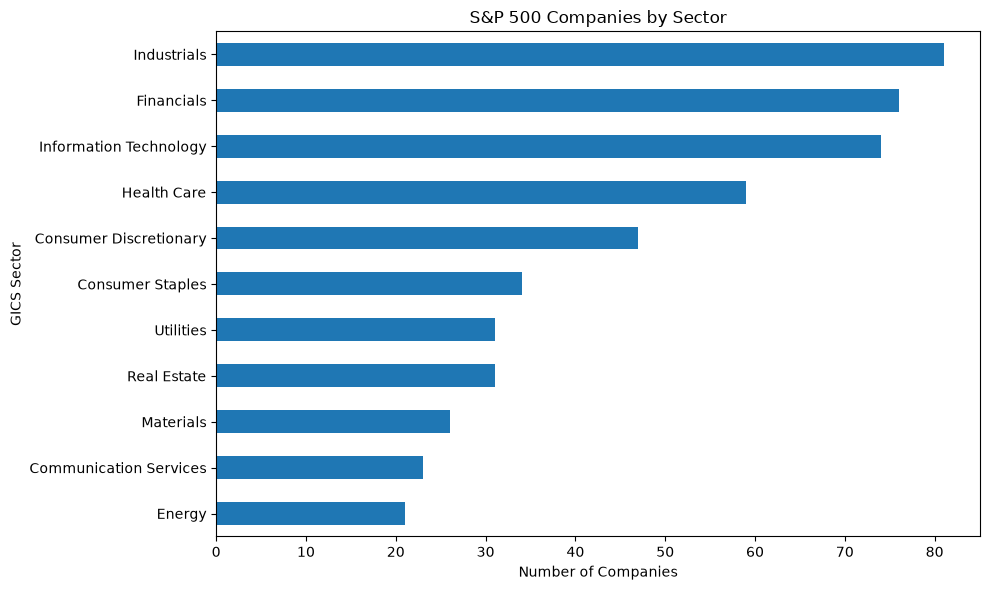

In [10]:
sector_counts.plot(kind='barh', figsize=(10, 6), title='S&P 500 Companies by Sector')
plt.xlabel('Number of Companies')
plt.ylabel('GICS Sector')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This shows how many companies fall into each GICS sector. Sectors with more companies naturally give more options for diversification within that sector, while smaller sectors may need to be represented by just one or two picks.

# Sector Share as a Percentage

In [11]:
sector_share = (sector_counts / sector_counts.sum() * 100).round(1)
sector_share

gics_sector
Industrials               16.1
Financials                15.1
Information Technology    14.7
Health Care               11.7
Consumer Discretionary     9.3
Consumer Staples           6.8
Utilities                  6.2
Real Estate                6.2
Materials                  5.2
Communication Services     4.6
Energy                     4.2
Name: count, dtype: float64

Turning the counts into percentages makes it easier to compare sector weight against a portfolio's actual allocation later on.

# Cross Check Against Jeffrey's Diversified Ticker List
On June 30, Jeffrey shared a diversified list of tickers in Discord to replace the original narrow QQQ and MAG7 heavy list. Below is that same list, organized by sector, checked against this wikipedia table to confirm which ones are individual companies versus ETFs.

In [12]:
jeffrey_tickers_by_sector = {
    "Broad equity": ["QQQ"],
    "Mega-cap tech": ["AAPL", "MSFT"],
    "Healthcare": ["LLY", "UNH"],
    "Financials": ["JPM", "V"],
    "Energy": ["XOM"],
    "Consumer staples": ["PG", "KO"],
    "Industrials": ["CAT"],
    "Defense": ["LMT"],
    "Real estate": ["VNQ"],
    "International": ["VXUS"],
    "Bonds": ["TLT", "AGG"],
    "Gold/commodities": ["GLD"],
    "Consumer discretionary": ["AMZN"],
    "Utilities": ["NEE"],
    "Communication": ["VZ"],
    "Benchmark": ["SPY"],
}

portfolio_tickers = [t for tickers in jeffrey_tickers_by_sector.values() for t in tickers]

matched = [t for t in portfolio_tickers if t in sp500['ticker'].values]
unmatched = [t for t in portfolio_tickers if t not in sp500['ticker'].values]

print(f"Matched tickers (individual companies): {matched}")
print(f"Unmatched tickers (likely ETFs): {unmatched}")

Matched tickers (individual companies): ['AAPL', 'MSFT', 'LLY', 'UNH', 'JPM', 'V', 'XOM', 'PG', 'KO', 'CAT', 'LMT', 'AMZN', 'NEE', 'VZ']
Unmatched tickers (likely ETFs): ['QQQ', 'VNQ', 'VXUS', 'TLT', 'AGG', 'GLD', 'SPY']


This confirms what we expected. The individual stock tickers all match up fine, while tickers like SPY, QQQ, AGG, GLD, VNQ, VXUS, and TLT don't show up since those are ETFs, not individual companies, so they were never going to be in this table.

# Sector Lookup for Matched Tickers

In [13]:
matched_sectors = sp500[sp500['ticker'].isin(matched)][['ticker', 'company_name', 'gics_sector']]
matched_sectors

,ticker,company_name,gics_sector
22,AMZN,Amazon,Consumer Discretionary
38,AAPL,Apple Inc.,Information Technology
89,CAT,Caterpillar Inc.,Industrials
114,KO,Coca-Cola Company (The),Consumer Staples
188,XOM,ExxonMobil,Energy
269,JPM,JPMorgan Chase,Financials
288,LLY,Lilly (Eli),Health Care
291,LMT,Lockheed Martin,Industrials
316,MSFT,Microsoft,Information Technology
334,NEE,NextEra Energy,Utilities


This gives a quick view of the sector each of the portfolio's individual stocks falls into, which will be useful once we start looking at how diversified the actual portfolio holdings are across sectors.

# Save EDA Outputs

In [14]:
PROCESSED_DATA_PATH = Path('../../../data/processed/source_data/wikipedia')
EDA_OUTPUT_PATH = Path("../../../data/processed/source_data/wikipedia/eda_outputs")
EDA_OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

In [15]:
sector_counts.to_csv(EDA_OUTPUT_PATH / "wikipedia_sector_counts.csv")
matched_sectors.to_csv(EDA_OUTPUT_PATH / "wikipedia_portfolio_ticker_sectors.csv", index=False)

# Final Summary

In this notebook, we explored the cleaned S&P 500 wikipedia dataset by checking for missing values and duplicates, looking at how companies break down by sector, and cross checking the tickers used in the rest of the project against this table.

This analysis will help us understand how diversified the portfolio's individual stock holdings are across sectors, which feeds into the diversification part of the project.

This is only the beginning of our analysis for this data source. Once we merge this with the price data, we can look at things like sector level returns and volatility instead of just sector counts.

## Key Takeaways
- The data is clean, no missing values or duplicate tickers.
- Sectors vary a lot in size, some sectors have far more companies than others.
- All the individual stock tickers used elsewhere in the project matched up fine in this table.
- The ETF tickers did not match, which is expected since they are not individual companies.
- This sector data is ready to be merged with the price data for the diversification analysis later on.